# Evaluation and operating threshold

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
from src.data_loader import load_partition, predictors, fingerprints
def report(name):
    display(Markdown((ROOT / 'reports' / name).read_text(encoding='utf-8')))
def figure(name):
    display(Image(filename=str(ROOT / 'figures' / name)))


In [2]:
comparison=pd.read_csv(ROOT/'reports/model_comparison.csv')
display(comparison)
display(pd.read_csv(ROOT/'reports/model_comparison_threshold_050.csv'))
report('Model_Evaluation_Report.md')

,model,threshold,n,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp,training_seconds,inference_seconds,inference_ms_per_row
0,Logistic Regression,0.17,52738,0.735826,0.576948,0.997524,0.731063,0.908917,0.862971,0.411346,0.002476,19870,13885,47,18936,23.665719,0.164486,0.003119
1,Random Forest,0.52,52738,0.835375,0.693795,0.971343,0.809438,0.967776,0.950611,0.241090,0.028657,25617,8138,544,18439,61.905887,0.631129,0.011967
2,XGBoost,0.49,52738,0.825799,0.680698,0.971975,0.800668,0.969827,0.954990,0.256406,0.028025,25100,8655,532,18451,89.790066,0.221392,0.004198


,model,n,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp
0,Logistic Regression,52738,0.736812,0.581364,0.960386,0.724286,0.908917,0.862971,0.388920,0.039614,20627,13128,752,18231
1,Random Forest,52738,0.827866,0.682540,0.975504,0.803140,0.967776,0.950611,0.255162,0.024496,25142,8613,465,18518
2,XGBoost,52738,0.829250,0.685962,0.969446,0.803431,0.969827,0.954990,0.249593,0.030554,25330,8425,580,18403


# Model evaluation

The validation-selected model is **XGBoost**, with operating threshold **0.49**.
On the primary test set of **52,738 flows**, attack recall is **97.20%**, precision **68.07%**, F1 **0.8007**, ROC-AUC **0.9698**, and average precision **0.9550**.
The model misses **532 attacks** (FNR **2.80%**) and flags **8,655 benign flows** (FPR **25.64%**).
These are historical benchmark results, not measured production effectiveness.

## Modeling methodology
Three model families are required: Logistic Regression as an interpretable linear baseline; Random Forest for nonlinear interactions; and XGBoost for boosted decision trees. Each is wrapped in the same sklearn-compatible feature and preprocessing pipeline. Standard scaling is necessary for the linear model and harmless for tree splits. No target/attack category or row ID is supplied to any estimator.

RandomizedSearchCV uses 4 candidate configurations per family, three stratified folds, seed 42 and average precision scoring on a fixed stratified subset of 30,000 training rows. This bounded search is computationally practical but not exhaustive. Winning hyperparameters are refit on all 80,648 development training rows; validation remains untouched by fitting. Weighting options are compared without SMOTE. Search results include train/CV scores and durations in `tuning_*.csv`. Training time includes tuning and full refit; inference time is a single batch measurement including preprocessing, hardware-dependent and not a production latency benchmark.

Model selection ranks validation average precision (area under the precision-recall step function). In this repository the column `pr_auc` means average precision, not trapezoidal integration. Thresholds from 0.01 through 0.99 are evaluated on validation only. Among thresholds meeting recall >= 0.95 and FPR <= 0.05, choose the highest F1, then lowest FPR, then highest threshold. If infeasible, fall back to highest validation F1 and disclose the failure. Constraint met for the selected model: **False**. The frozen threshold is **0.49**. The model is not refit on validation, so its threshold applies to the exact saved estimator. The shared validation set is used for two selections, which can make validation performance optimistic; the final test provides a separate check.


## Validation comparison

| model               |   cv_pr_auc |   pr_auc |     f1 |   threshold | constraint_met   |
|:--------------------|------------:|---------:|-------:|------------:|:-----------------|
| Logistic Regression |      0.9586 |   0.9611 | 0.9088 |      0.1700 | False            |
| Random Forest       |      0.9809 |   0.9829 | 0.9319 |      0.5200 | False            |
| XGBoost             |      0.9816 |   0.9843 | 0.9344 |      0.4900 | False            |

## Final primary test comparison
All thresholds were frozen on validation. This table describes final evaluation; it is not a new model-selection step.

| model               |   accuracy |   precision |   recall |     f1 |   roc_auc |   pr_auc |    fpr |    fnr |   training_seconds |   inference_seconds |
|:--------------------|-----------:|------------:|---------:|-------:|----------:|---------:|-------:|-------:|-------------------:|--------------------:|
| Logistic Regression |     0.7358 |      0.5769 |   0.9975 | 0.7311 |    0.9089 |   0.8630 | 0.4113 | 0.0025 |            23.6657 |              0.1645 |
| Random Forest       |     0.8354 |      0.6938 |   0.9713 | 0.8094 |    0.9678 |   0.9506 | 0.2411 | 0.0287 |            61.9059 |              0.6311 |
| XGBoost             |     0.8258 |      0.6807 |   0.9720 | 0.8007 |    0.9698 |   0.9550 | 0.2564 | 0.0280 |            89.7901 |              0.2214 |

The model with the highest observed test recall is **Logistic Regression**. The lowest observed FPR belongs to **Random Forest**. The recommendation remains the validation-selected **XGBoost** for an educational prototype, subject to the limitations below. `model_comparison_threshold_050.csv` supplies a common-threshold comparison so each model's threshold trade-off is visible.

## Security implications
The selected model generates 8,655 false alerts and misses 532 attack flows in this test. False alerts consume investigation time; missed attack flows represent coverage gaps, but a flow is not the same unit as an incident. Lowering thresholds generally catches more attacks while increasing false alerts. The lowest-recall attack category is **Fuzzers**; review support and confidence intervals before generalizing from rare categories.

## Targets and recommendation
F1 target >= 0.90 achieved: **False**. ROC-AUC target >= 0.95 achieved: **True**. Validation constraint attainment does not guarantee the same constraint on test or live data. Use an offline or shadow-mode trial with analyst review, never automatic blocking from this prototype.

## Operational workload scenario
If a future population retained this test FPR, every 10,000 benign flows would produce approximately 2,564 false alerts. This is a conditional arithmetic illustration, not a traffic-volume forecast. Deployment precision also depends on attack prevalence. Expected alerts for N flows and attack prevalence p are N[p*recall + (1-p)*FPR]. Analyst effort equals alerts times average review time; neither actual costs nor savings are available, so no monetary ROI is claimed.

## Limits of the estimate
The primary population excludes exact development overlaps and repeated test flows, which affects prevalence and comparability. See the secondary published-test metrics. No temporal, cross-network or current-attack holdout exists here. Scores are uncalibrated. Adjacent flows may be correlated; binomial uncertainty intervals for groups do not address that dependence.


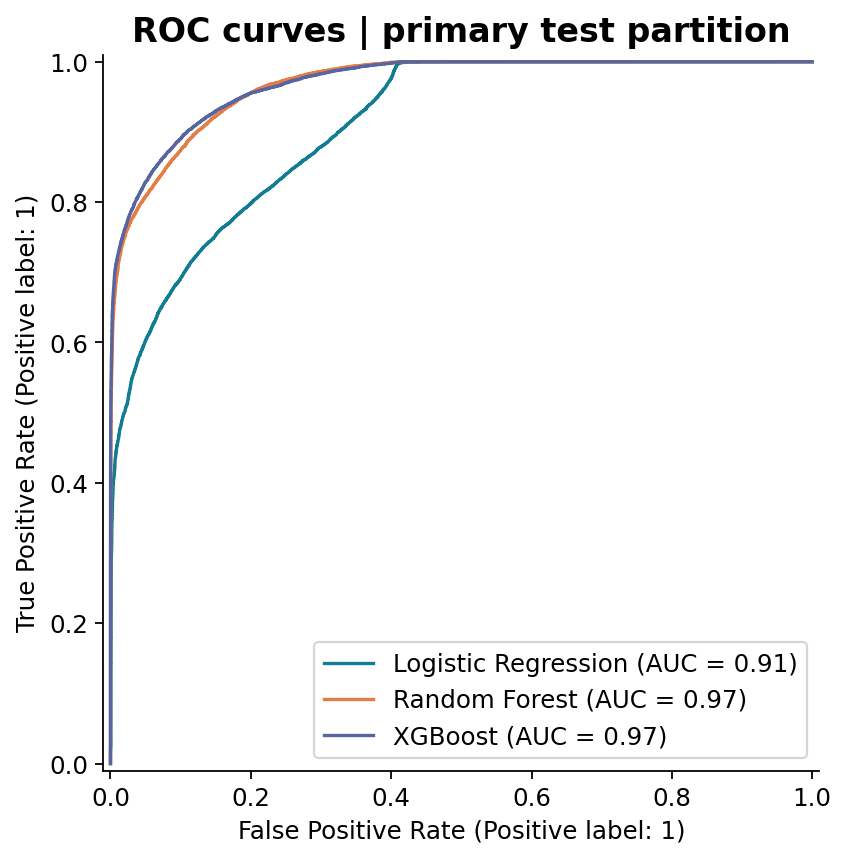

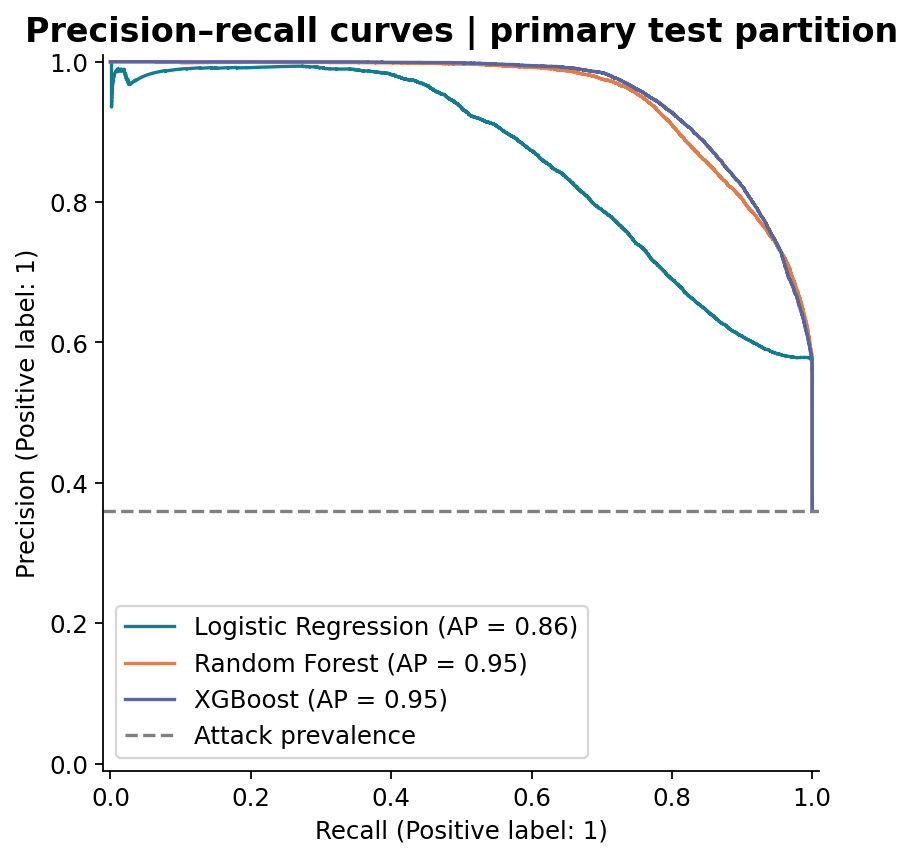

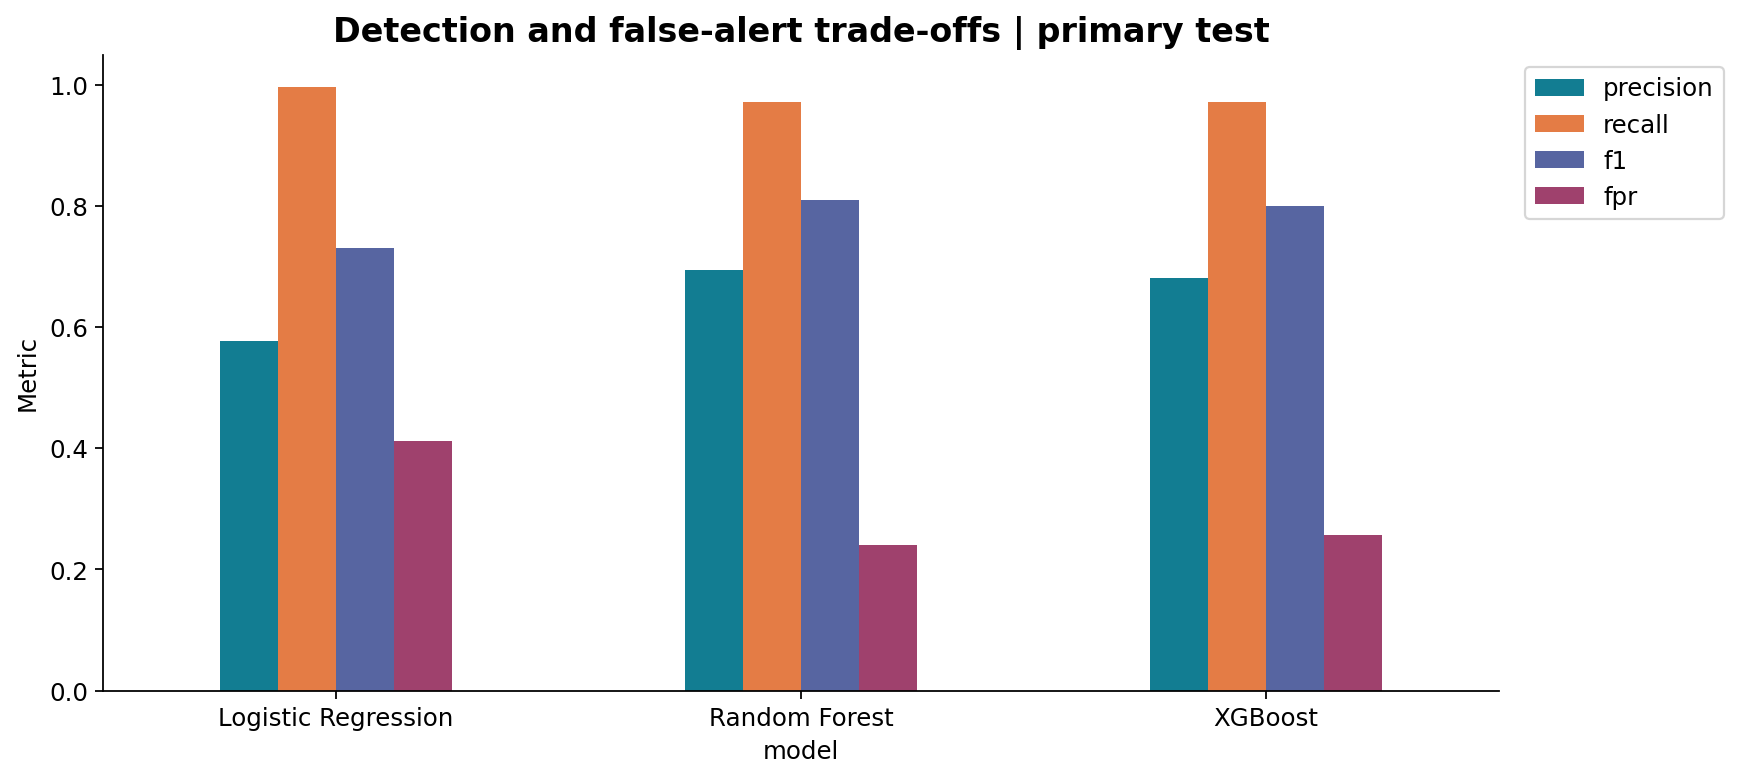

In [3]:
figure('roc_curves.png')
figure('pr_curves.png')
figure('model_comparison.png')

Interpretation: discrimination scores do not specify alert workload at the operating threshold. Compare precision and FPR alongside attack recall. The winner was fixed by validation, even if another family has a higher test F1.

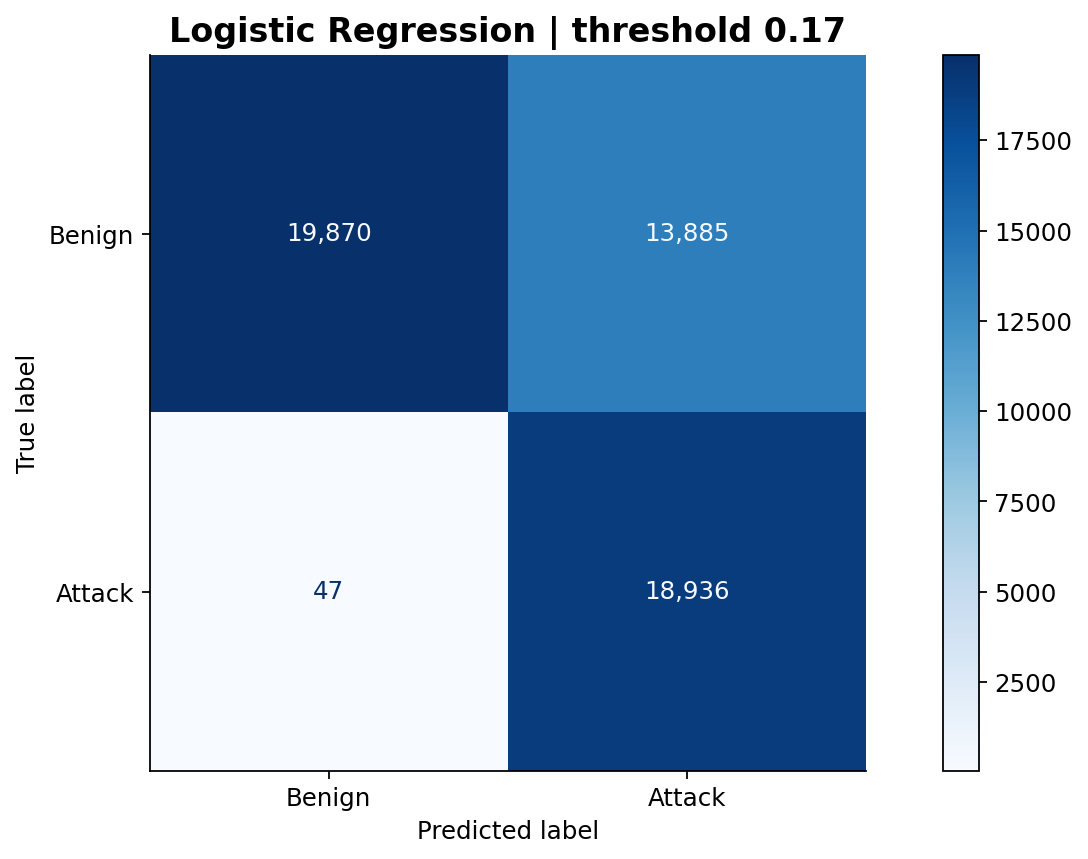

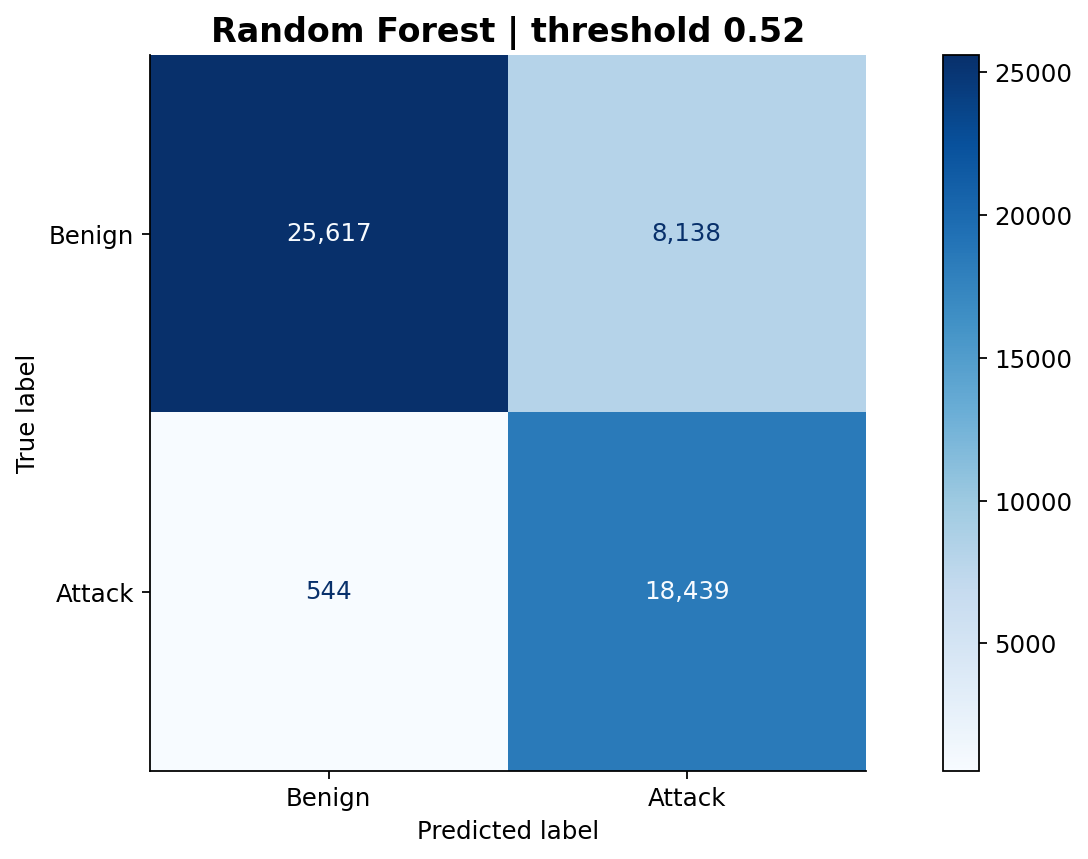

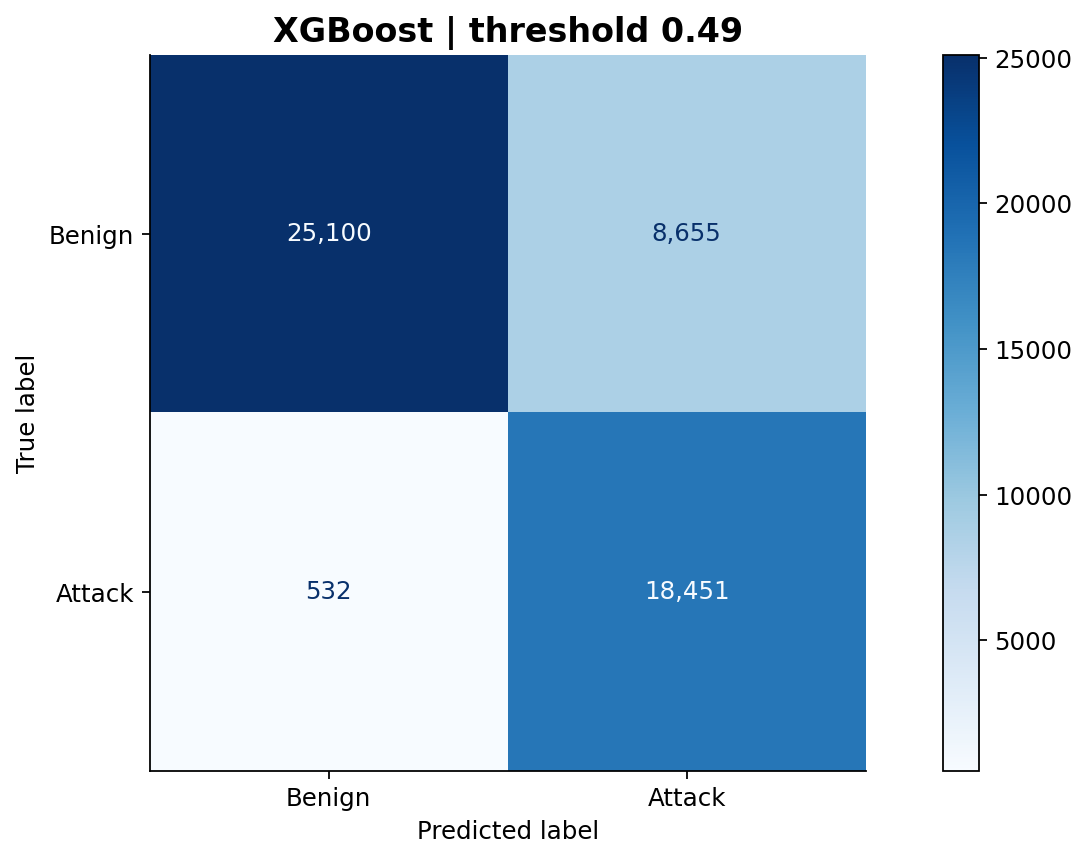

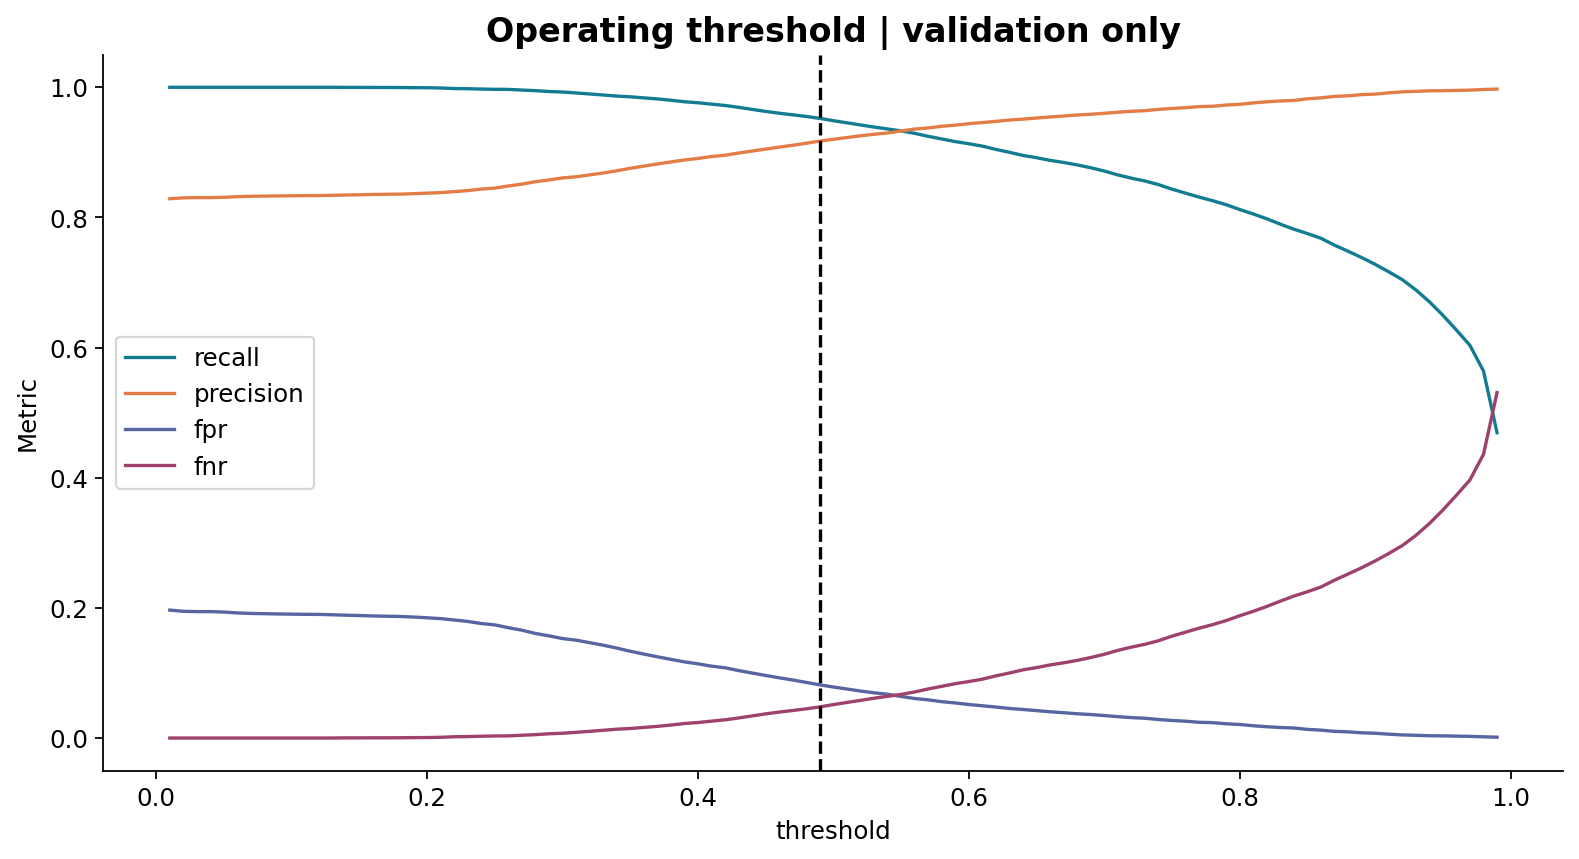

In [4]:
for name in ['logistic_regression','random_forest','xgboost']:
    figure(f'confusion_{name}.png')
figure('threshold_tradeoff.png')

Interpretation: threshold curves use validation only. Test false-alert rates can exceed validation rates under distribution shift. Unmet operating constraints require disclosure and further local validation, not test-based threshold retuning.

In [5]:
from src.evaluate import metrics
import joblib
from src.predict import predict
test=pd.read_csv(ROOT/'data/processed/test.csv')
model=joblib.load(ROOT/'models/final_model.joblib')
meta=json.loads((ROOT/'models/metadata.json').read_text())
result=predict(test.iloc[:100],model,meta)
assert len(result)==100
display(result.head())
print('Published test secondary:',json.loads((ROOT/'reports/published_test_secondary.json').read_text()))

Published test secondary: {'n': 82332, 'accuracy': 0.8722003595199922, 'precision': 0.8185395314787701, 'recall': 0.986609900291185, 'f1': 0.8947505301484415, 'roc_auc': 0.9846544446259548, 'pr_auc': 0.9886226640730553, 'fpr': 0.26797297297297296, 'fnr': 0.013390099708814966, 'tn': 27085, 'fp': 9915, 'fn': 607, 'tp': 44725}


,prediction,attack_probability,threshold
0,Attack,0.904793,0.49
1,Attack,0.845193,0.49
2,Attack,0.707994,0.49
3,Attack,0.698386,0.49
4,Attack,0.767701,0.49
